In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')

import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
train=pd.read_csv('movies_train.csv')

## 1. 감독 데뷔 여부(전에 찍은 작품수가 0인 감독과 아닌 감독) × 관객수

### EDA

In [ ]:
train['is_debut'] = train['dir_prev_num'] == 0
train['log_box_off'] = np.log1p(train['box_off_num'])

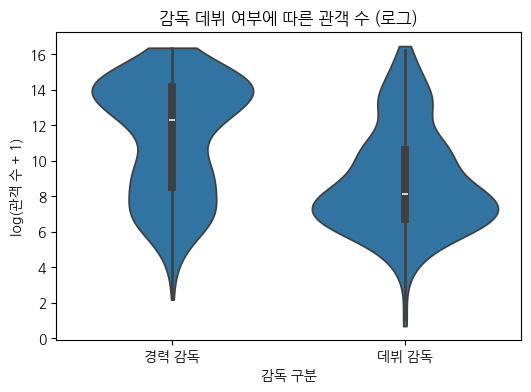

            중앙값            평균  영화 수
감독 구분                              
경력 감독  222258.0  1.146932e+06   270
데뷔 감독    3401.5  3.492043e+05   330


In [ ]:
plt.figure(figsize=(6,4))
sns.violinplot(x='is_debut', y='log_box_off', data=train, cut=0)
plt.xticks([0,1], ['경력 감독', '데뷔 감독'])
plt.title('감독 데뷔 여부에 따른 관객 수 (로그)')
plt.xlabel('감독 구분')
plt.ylabel('log(관객 수 + 1)')
plt.show()

result = train.groupby('is_debut')['box_off_num'].agg(['median','mean','count'])
result.index = result.index.map({False: '경력 감독', True: '데뷔 감독'})
result.index.name = '감독 구분'
result.columns = ['중앙값', '평균', '영화 수']
print(result)

## 2. 상영시간 x 스탭수

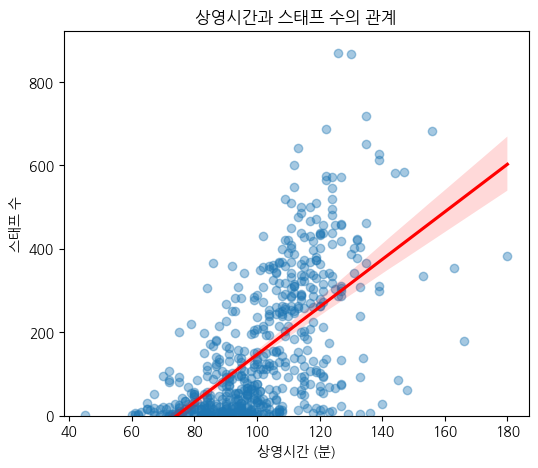

상관계수: 0.623


In [ ]:
plt.figure(figsize=(6,5))
sns.regplot(x='time', y='num_staff', data=train,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.ylim(bottom=0)          # y축을 0부터 시작
plt.title('상영시간과 스태프 수의 관계')
plt.xlabel('상영시간 (분)')
plt.ylabel('스태프 수')
plt.show()

corr = train['time'].corr(train['num_staff'])
print(f"상관계수: {corr:.3f}")

##3. 장르 x 관객수

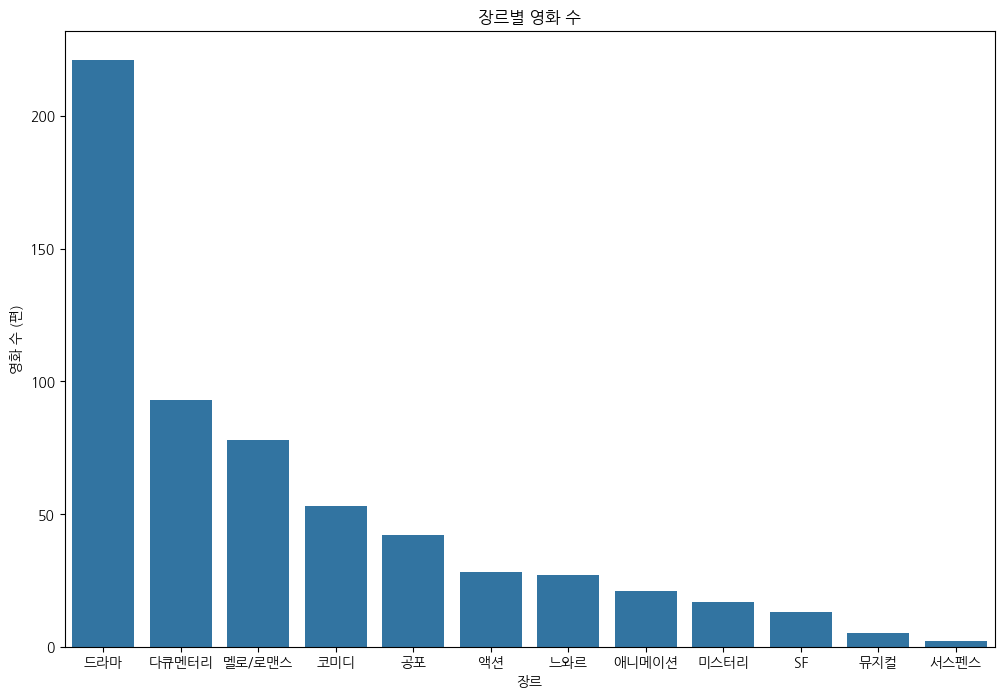

In [ ]:
genre_count = train['genre'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_count.index, y=genre_count.values)
plt.title('장르별 영화 수')
plt.xlabel('장르')
plt.ylabel('영화 수 (편)')
plt.show()

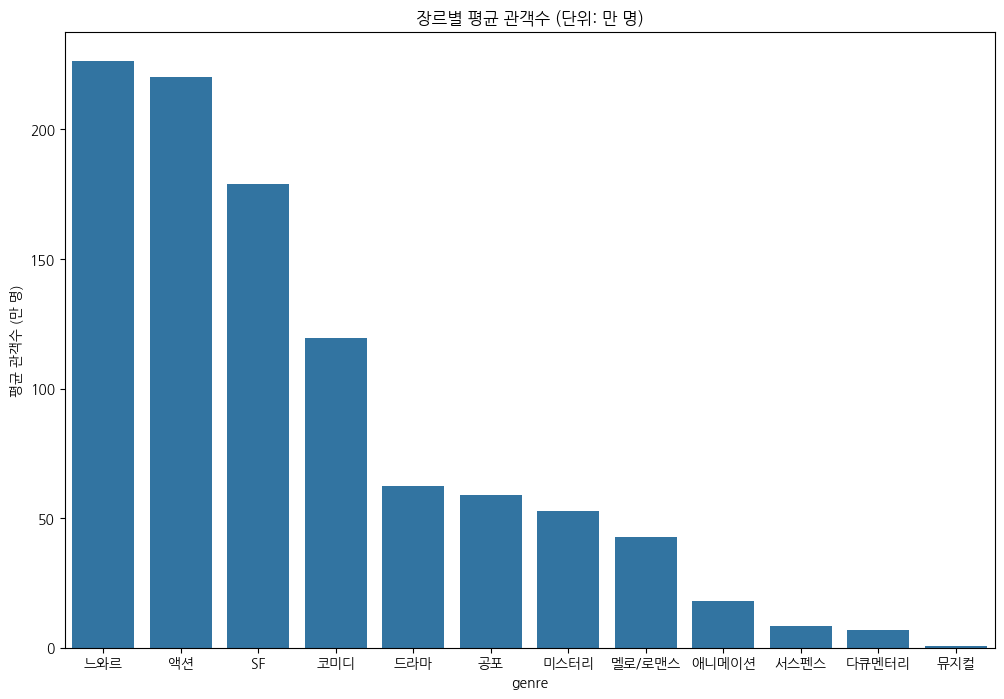

In [ ]:
genre_num = train.groupby('genre')['box_off_num'].aggregate('mean') / 10000
genre_num_sort = genre_num.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_num_sort.index, y=genre_num_sort.values)
plt.title('장르별 평균 관객수 (단위: 만 명)')
plt.ylabel('평균 관객수 (만 명)')
plt.show()

### EDA

In [ ]:
train['log_box_off'] = np.log1p(train['box_off_num'])

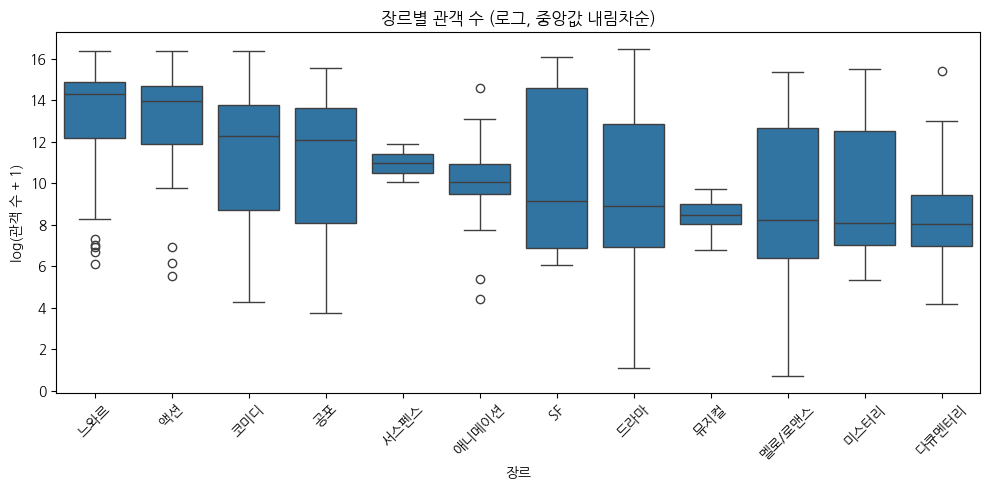

              중앙값            평균  영화 수
장르                                   
느와르     1646142.0  2.263695e+06    27
액션      1147846.5  2.203974e+06    28
코미디      210775.0  1.193914e+06    53
공포       179810.0  5.908325e+05    42
서스펜스      82611.0  8.261100e+04     2
애니메이션     23802.0  1.819267e+05    21
SF         9323.0  1.788346e+06    13
드라마        7173.0  6.256898e+05   221
뮤지컬        4778.0  6.627000e+03     5
멜로/로맨스     3653.0  4.259680e+05    78
미스터리       3199.0  5.275482e+05    17
다큐멘터리      3044.0  6.717226e+04    93


In [ ]:
order = train.groupby('genre')['box_off_num'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,5))
sns.boxplot(x='genre', y='log_box_off', data=train, order=order)
plt.title('장르별 관객 수 (로그, 중앙값 내림차순)')
plt.xlabel('장르')
plt.ylabel('log(관객 수 + 1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

result = train.groupby('genre')['box_off_num'].agg(['median','mean','count']).sort_values('median', ascending=False)
result.columns = ['중앙값', '평균', '영화 수']
result.index.name = '장르'
print(result)

## 4. 배급사별(Top6 와 나머지) x 관객수

### EDA

In [ ]:
distributor_counts = train['distributor'].value_counts()
major_distributors = distributor_counts[distributor_counts >= 26].index
train['is_major_dist'] = train['distributor'].isin(major_distributors)

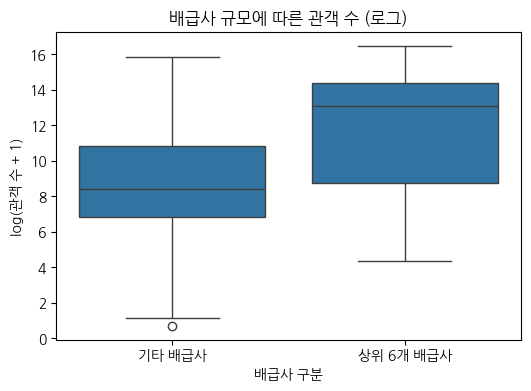

                중앙값            평균  영화 수
배급사 구분                                 
기타 배급사       4449.0  2.325812e+05   383
상위 6개 배급사  472695.0  1.547606e+06   217


In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='is_major_dist', y='log_box_off', data=train)
plt.xticks([0,1], ['기타 배급사', '상위 6개 배급사'])
plt.title('배급사 규모에 따른 관객 수 (로그)')
plt.xlabel('배급사 구분')
plt.ylabel('log(관객 수 + 1)')
plt.show()

result = train.groupby('is_major_dist')['box_off_num'].agg(['median','mean','count'])
result.index = result.index.map({False: '기타 배급사', True: '상위 6개 배급사'})
result.index.name = '배급사 구분'
result.columns = ['중앙값', '평균', '영화 수']
print(result)

## 5. 스텝수 x 상영시간

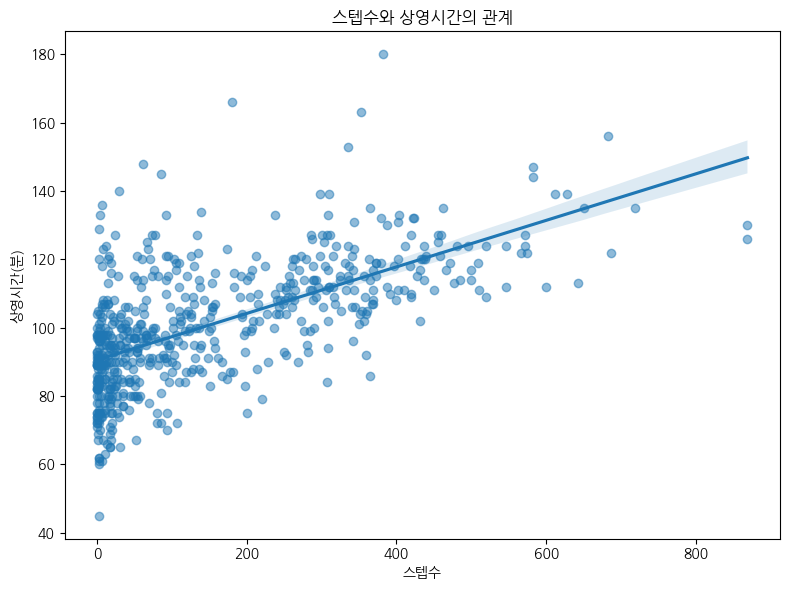

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(data=train,x='num_staff',y='time',scatter_kws={'alpha': 0.5})

plt.title('스텝수와 상영시간의 관계')
plt.xlabel('스텝수')
plt.ylabel('상영시간(분)')

plt.tight_layout()
plt.show()

피어슨 상관분석

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(
    train['num_staff'],
    train['time']
)

print('Pearson correlation:', r)
print('p-value:', p)

Pearson correlation: 0.6232051619606053
p-value: 7.49331326778995e-66


## 6. 대형 배급사가 선점하는 장르, 상영등급, 개봉일

### EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ----------------------------------------------------
# 1. 파생변수 생성 (대형 배급사 여부, 개봉월)
# ----------------------------------------------------
# 개봉일 datetime 변환 및 월 추출
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_month'] = train['release_time'].dt.month

# 대형 배급사 정의 (상위 4대 메이저 배급사 기준: CJ, 롯데, NEW, 쇼박스)
major_distributors = ['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)쇼박스']

# '대형' vs '중소/기타' 구분 컬럼 생성
train['is_major'] = train['distributor'].apply(
    lambda x: '대형 배급사' if any(m in str(x) for m in ['CJ', '롯데', 'NEW', '쇼박스']) else '중소/기타 배급사'
)

print("배급사 분류별 영화 수:")
print(train['is_major'].value_counts())

배급사 분류별 영화 수:
is_major
중소/기타 배급사    422
대형 배급사       178
Name: count, dtype: int64


### 그래프


[genre] 카이제곱 검정 결과:
 - Chi-square: 74.7823, p-value: 1.4922e-11
 -> [유의미함] '배급사 규모'와 'genre' 간에 통계적으로 유의한 연관성이 있습니다. (p < 0.05)

[screening_rat] 카이제곱 검정 결과:
 - Chi-square: 42.4223, p-value: 3.2641e-09
 -> [유의미함] '배급사 규모'와 'screening_rat' 간에 통계적으로 유의한 연관성이 있습니다. (p < 0.05)

[release_month] 카이제곱 검정 결과:
 - Chi-square: 13.3836, p-value: 2.6900e-01
 -> [유의하지 않음] '배급사 규모'와 'release_month' 간의 독립성을 기각할 수 없습니다.


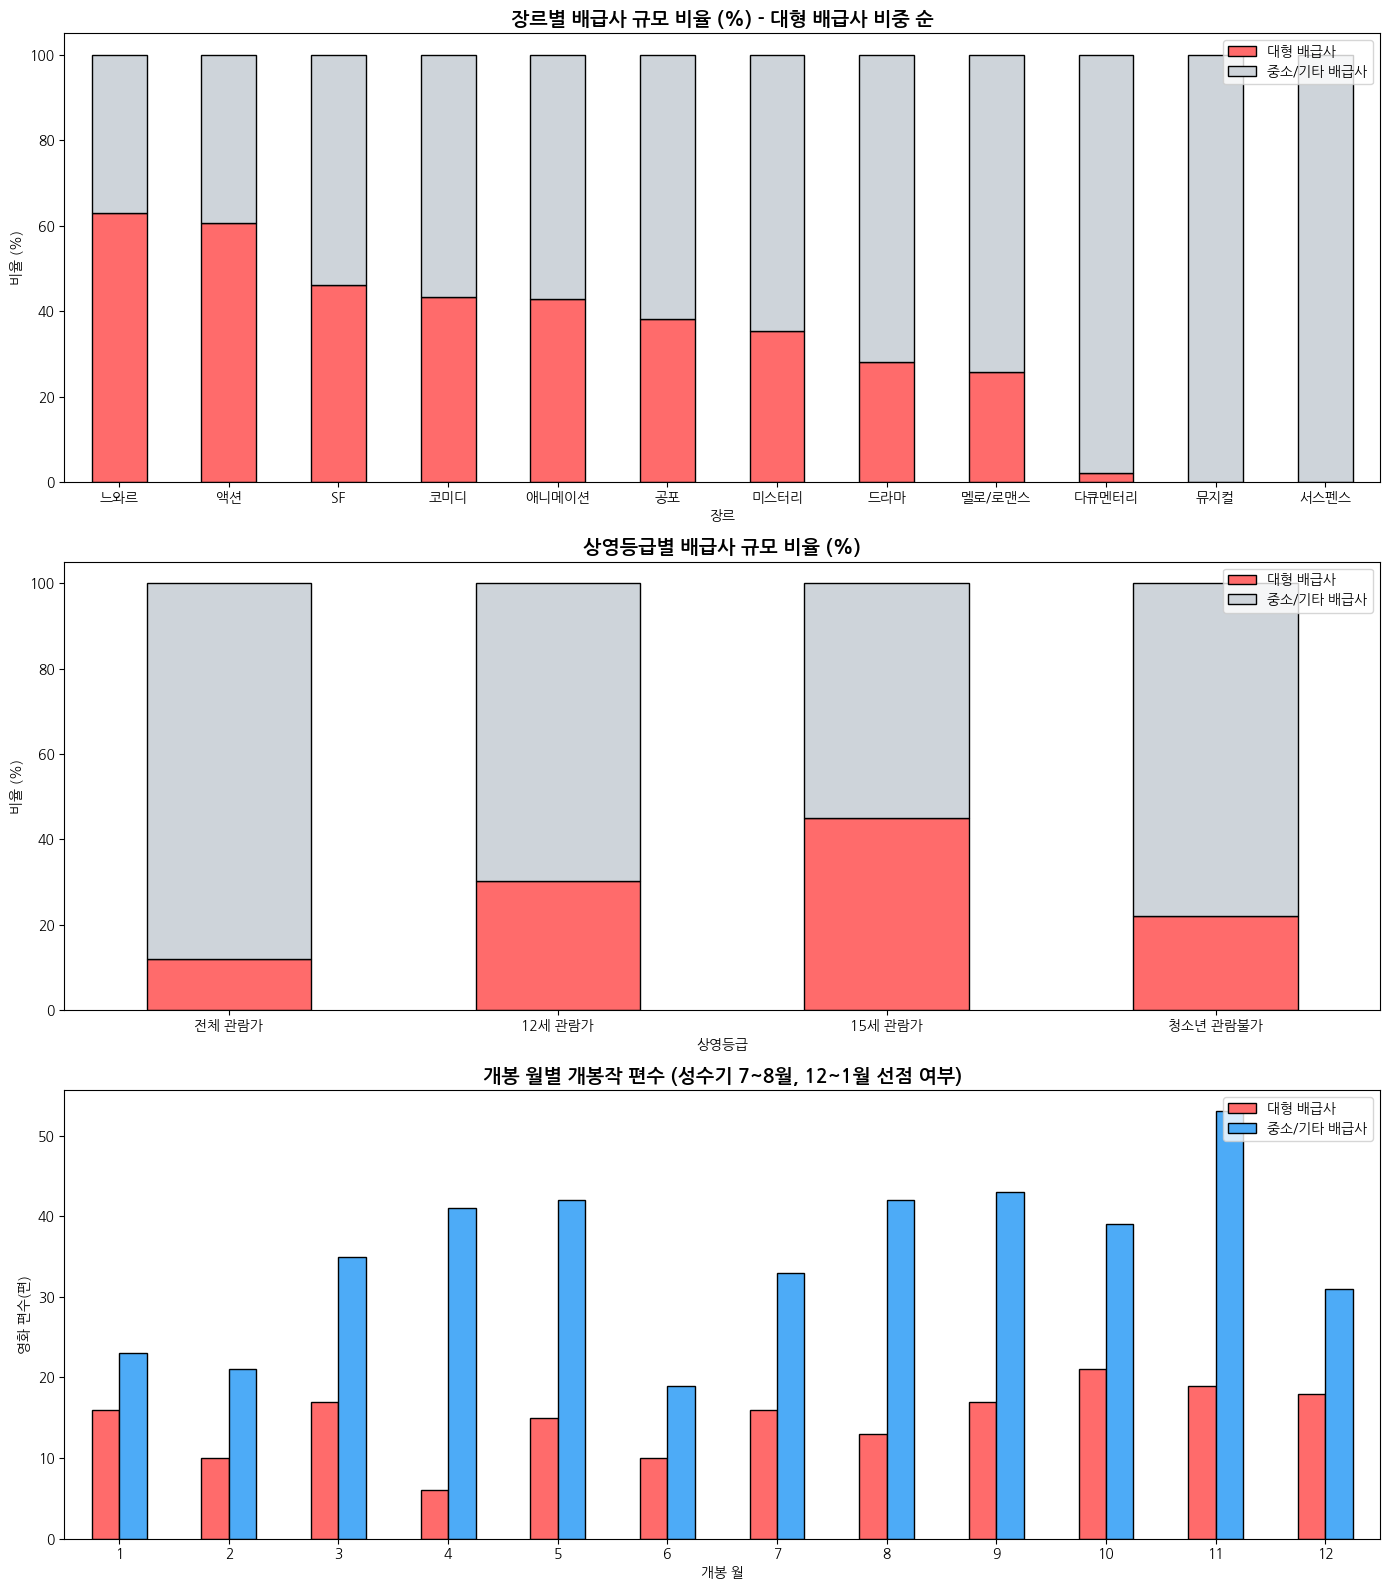

In [ ]:
# ----------------------------------------------------
# 2. 통계적 유의성 검정 (카이제곱 독립성 검정)
# ----------------------------------------------------
def check_significance(col_name):
    cross_tab = pd.crosstab(train['is_major'], train[col_name])
    chi2, p, dof, _ = chi2_contingency(cross_tab)
    print(f"\n[{col_name}] 카이제곱 검정 결과:")
    print(f" - Chi-square: {chi2:.4f}, p-value: {p:.4e}")
    if p < 0.05:
        print(f" -> [유의미함] '배급사 규모'와 '{col_name}' 간에 통계적으로 유의한 연관성이 있습니다. (p < 0.05)")
    else:
        print(f" -> [유의하지 않음] '배급사 규모'와 '{col_name}' 간의 독립성을 기각할 수 없습니다.")
    return cross_tab

tab_genre = check_significance('genre')
tab_rating = check_significance('screening_rat')
tab_month = check_significance('release_month')


# ----------------------------------------------------
# 3. 시각화 (장르, 상영등급, 개봉월별 배급사 점유 비율)
# ----------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# 3-1. 장르별 대형 배급사 영화 분포 및 비중
genre_pct = pd.crosstab(train['genre'], train['is_major'], normalize='index') * 100
genre_pct = genre_pct.sort_values(by='대형 배급사', ascending=False)
genre_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#ff6b6b', '#ced4da'], edgecolor='black')
axes[0].set_title('장르별 배급사 규모 비율 (%) - 대형 배급사 비중 순', fontsize=14, fontweight='bold')
axes[0].set_ylabel('비율 (%)')
axes[0].set_xlabel('장르')
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=0)

# 3-2. 상영등급별 배급사 규모 비율
rating_order = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']
rating_pct = pd.crosstab(train['screening_rat'], train['is_major'], normalize='index').reindex(rating_order) * 100
rating_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff6b6b', '#ced4da'], edgecolor='black')
axes[1].set_title('상영등급별 배급사 규모 비율 (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xlabel('상영등급')
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

# 3-3. 개봉월별 대형 배급사 영화 수 (성수기 선점 확인)
month_cnt = pd.crosstab(train['release_month'], train['is_major'])
month_cnt.plot(kind='bar', ax=axes[2], color=['#ff6b6b', '#4dabf7'], edgecolor='black')
axes[2].set_title('개봉 월별 개봉작 편수 (성수기 7~8월, 12~1월 선점 여부)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('영화 편수(편)')
axes[2].set_xlabel('개봉 월')
axes[2].legend(['대형 배급사', '중소/기타 배급사'], loc='upper right')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. 영화를 1편만 제작한 배급사의 영화 중 관객 수가 많은 영화의 공통점 찾기

### EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

# -------------------------------------------------------------------------
# 1. 1편만 배급한 배급사 영화 추출 및 집단 분류
# -------------------------------------------------------------------------
# 배급 편수가 1편인 배급사 필터링
dist_counts = train['distributor'].value_counts()
single_distributors = dist_counts[dist_counts == 1].index
single_df = train[train['distributor'].isin(single_distributors)].copy()

# 감독 이전 관객수 결측치 대체 (0명)
single_df['dir_prev_bfnum'] = single_df['dir_prev_bfnum'].fillna(0)

# 관객 수 상위 25% (Q3) 기준 집단 분리
threshold = single_df['box_off_num'].quantile(0.75)
high_group_name = f'상위 25% (관객 > {int(threshold):,}명)'
low_group_name = '일반/하위작'

single_df['success_group'] = single_df['box_off_num'].apply(
    lambda x: high_group_name if x >= threshold else low_group_name
)

print(f"전체 영화 수: {len(train)}편 | 1편 배급사 영화 수: {len(single_df)}편")
print(f"상위 흥행 기준 관객 수: {int(threshold):,}명 이상\n")
print("집단별 영화 편수:")
print(single_df['success_group'].value_counts())

전체 영화 수: 600편 | 1편 배급사 영화 수: 102편
상위 흥행 기준 관객 수: 14,395명 이상

집단별 영화 편수:
success_group
일반/하위작                   76
상위 25% (관객 > 14,395명)    26
Name: count, dtype: int64


### 그래프


1) 수치형 변수 검정 (Mann-Whitney U Test)
   - 가설: 상위 흥행작과 일반작 간의 값에 통계적으로 유의한 차이가 있는가?
[num_staff       ]  Statistic:   1497.5 | p-value: 9.1487e-05  -->  [유의미한 차이 O] (p < 0.05)
[dir_prev_bfnum  ]  Statistic:   1224.5 | p-value: 3.3819e-02  -->  [유의미한 차이 O] (p < 0.05)
[time            ]  Statistic:   1427.5 | p-value: 7.4525e-04  -->  [유의미한 차이 O] (p < 0.05)
[num_actor       ]  Statistic:   1086.0 | p-value: 4.4567e-01  -->  [차이 없음 X] (유의하지 않음)

2) 범주형 변수 검정 (Chi-Square Test)
   - 가설: 흥행 그룹과 장르 / 상영등급 간에 통계적으로 유의한 연관성이 있는가?
[genre           ]  Chi2:       18.4508 | p-value: 7.1694e-02  -->  [연관 없음 X] (독립적)
[screening_rat   ]  Chi2:        6.9111 | p-value: 7.4786e-02  -->  [연관 없음 X] (독립적)


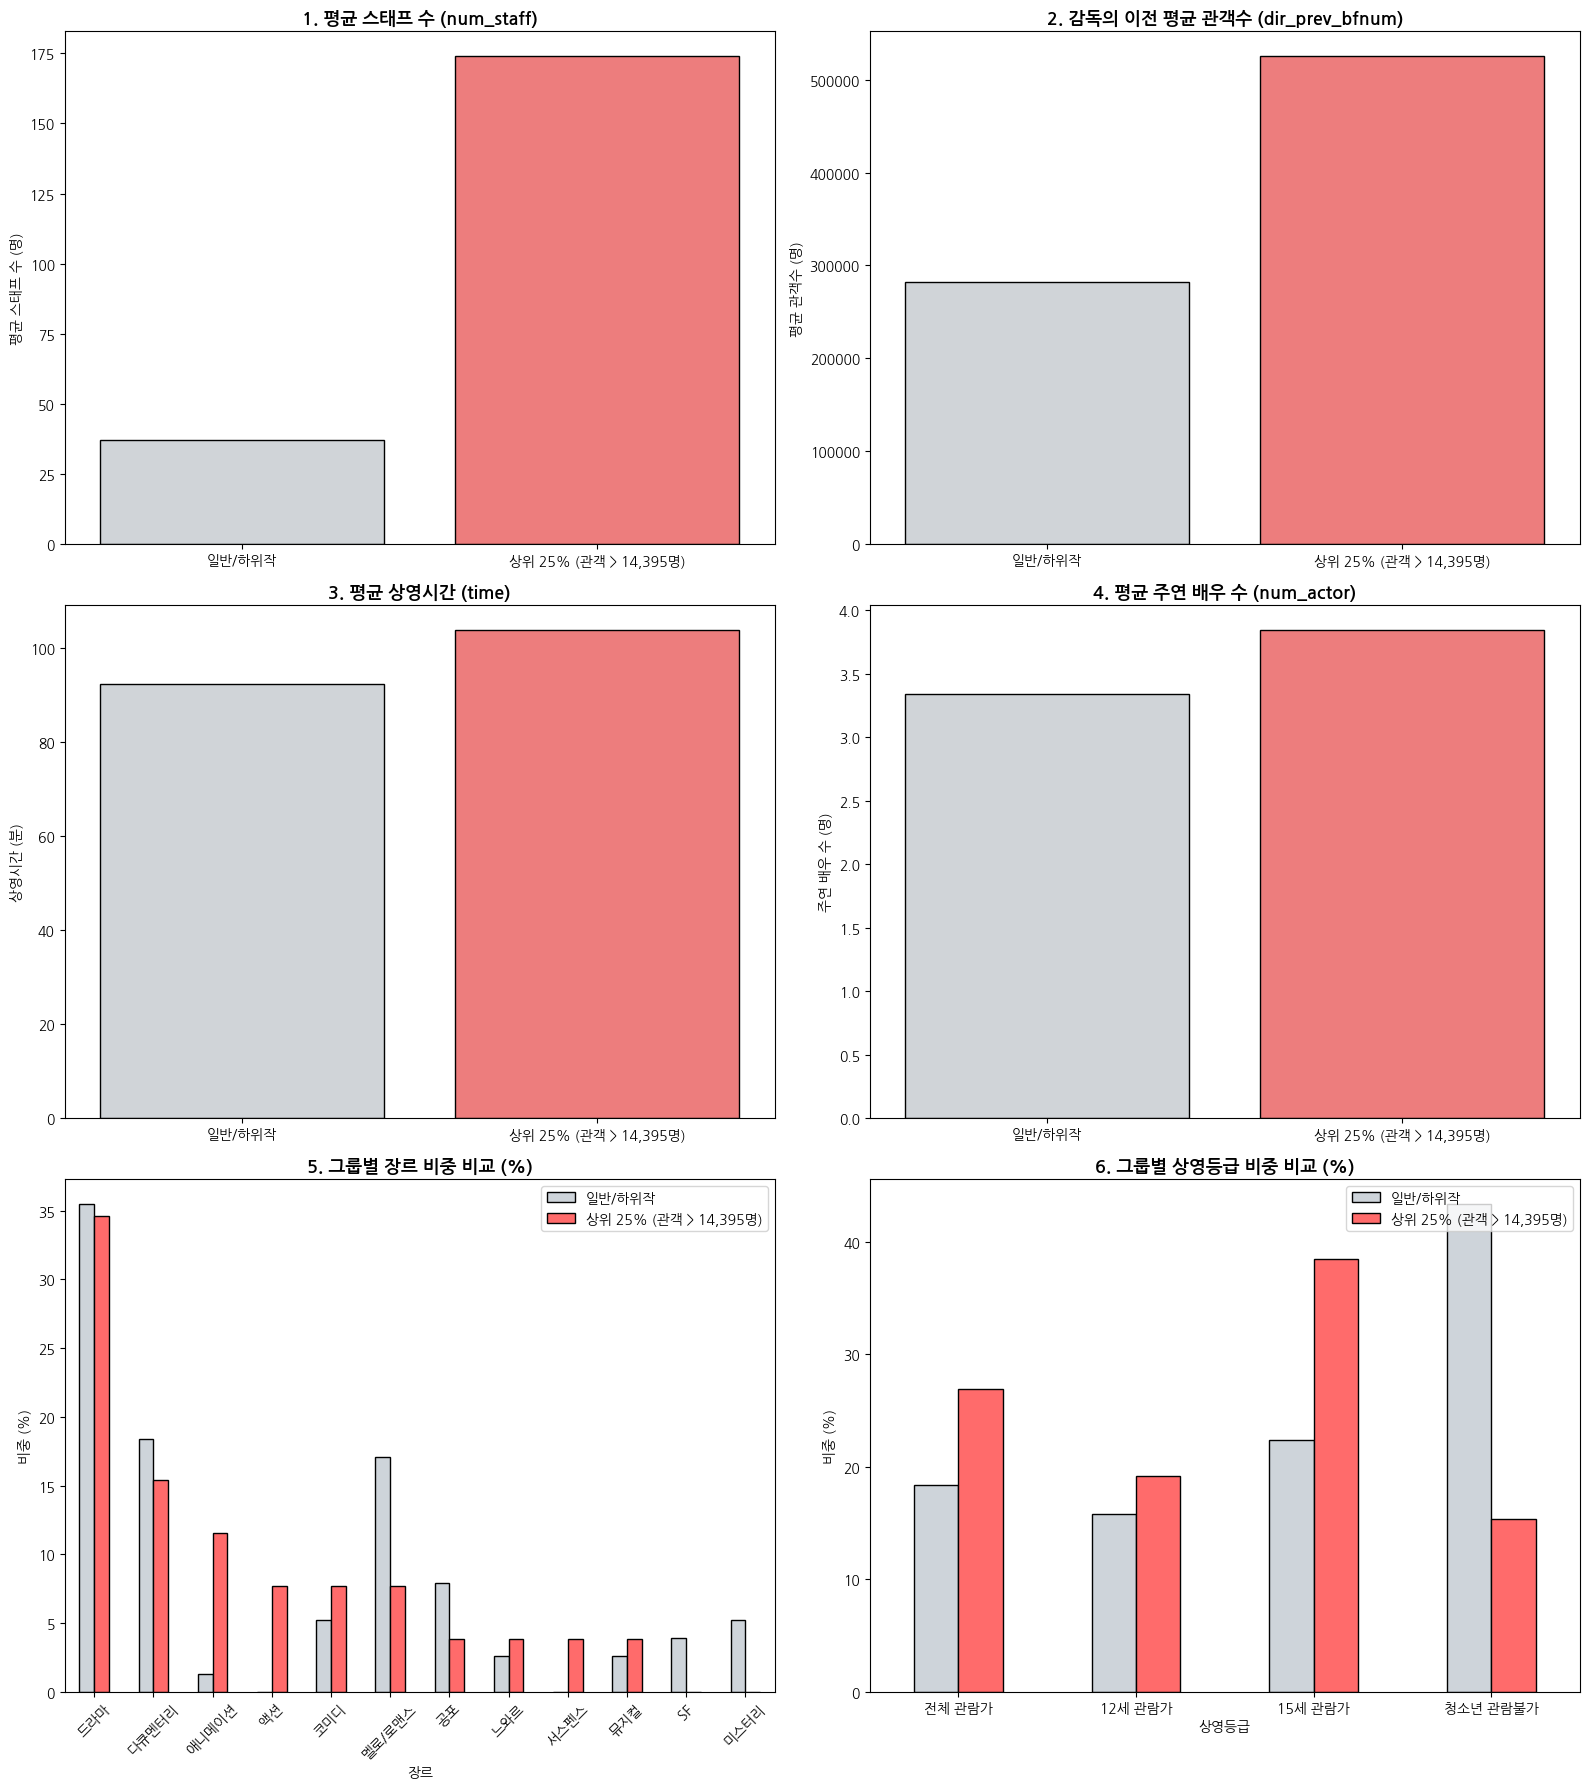

In [ ]:
# -------------------------------------------------------------------------
# 2. 6개 주요 컬럼에 대한 통계적 검정
# -------------------------------------------------------------------------
print("\n" + "=" * 65)
print("1) 수치형 변수 검정 (Mann-Whitney U Test)")
print("   - 가설: 상위 흥행작과 일반작 간의 값에 통계적으로 유의한 차이가 있는가?")
print("=" * 65)

num_cols = ['num_staff', 'dir_prev_bfnum', 'time', 'num_actor']

for col in num_cols:
    group_high = single_df[single_df['success_group'] == high_group_name][col].dropna()
    group_low = single_df[single_df['success_group'] == low_group_name][col].dropna()

    stat, p = mannwhitneyu(group_high, group_low, alternative='two-sided')
    sig = "[유의미한 차이 O] (p < 0.05)" if p < 0.05 else "[차이 없음 X] (유의하지 않음)"
    print(f"[{col:16s}]  Statistic: {stat:8.1f} | p-value: {p:.4e}  -->  {sig}")

print("\n" + "=" * 65)
print("2) 범주형 변수 검정 (Chi-Square Test)")
print("   - 가설: 흥행 그룹과 장르 / 상영등급 간에 통계적으로 유의한 연관성이 있는가?")
print("=" * 65)

cat_cols = ['genre', 'screening_rat']

for col in cat_cols:
    cross_tab = pd.crosstab(single_df['success_group'], single_df[col])
    chi2, p, dof, _ = chi2_contingency(cross_tab)
    sig = "[유의미한 연관 O] (p < 0.05)" if p < 0.05 else "[연관 없음 X] (독립적)"
    print(f"[{col:16s}]  Chi2: {chi2:13.4f} | p-value: {p:.4e}  -->  {sig}")


# -------------------------------------------------------------------------
# 3. 6개 컬럼 전체 시각화 (3행 2열 레이아웃)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
palette_choice = ['#ced4da', '#ff6b6b']  # 회색: 일반/하위작, 빨간색: 상위 흥행작

# [1/6] 스태프 수 (num_staff)
sns.barplot(
    data=single_df, x='success_group', y='num_staff',
    ax=axes[0, 0], palette=palette_choice, ci=None, edgecolor='black'
)
axes[0, 0].set_title('1. 평균 스태프 수 (num_staff)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('평균 스태프 수 (명)')

# [2/6] 감독의 이전 관객수 (dir_prev_bfnum)
sns.barplot(
    data=single_df, x='success_group', y='dir_prev_bfnum',
    ax=axes[0, 1], palette=palette_choice, ci=None, edgecolor='black'
)
axes[0, 1].set_title('2. 감독의 이전 평균 관객수 (dir_prev_bfnum)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('평균 관객수 (명)')

# [3/6] 상영시간 (time)
sns.barplot(
    data=single_df, x='success_group', y='time',
    ax=axes[1, 0], palette=palette_choice, ci=None, edgecolor='black'
)
axes[1, 0].set_title('3. 평균 상영시간 (time)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('상영시간 (분)')

# [4/6] 주연 배우 수 (num_actor)
sns.barplot(
    data=single_df, x='success_group', y='num_actor',
    ax=axes[1, 1], palette=palette_choice, ci=None, edgecolor='black'
)
axes[1, 1].set_title('4. 평균 주연 배우 수 (num_actor)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('주연 배우 수 (명)')

# [5/6] 장르 비중 비교 (genre)
genre_cross = pd.crosstab(single_df['genre'], single_df['success_group'], normalize='columns') * 100
genre_cross = genre_cross[[low_group_name, high_group_name]]  # 컬럼 순서 고정 (일반작, 상위작)
genre_cross = genre_cross.sort_values(by=high_group_name, ascending=False)
genre_cross.plot(kind='bar', ax=axes[2, 0], color=palette_choice, edgecolor='black')
axes[2, 0].set_title('5. 그룹별 장르 비중 비교 (%)', fontsize=13, fontweight='bold')
axes[2, 0].set_ylabel('비중 (%)')
axes[2, 0].set_xlabel('장르')
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].legend(loc='upper right')

# [6/6] 상영등급 비중 비교 (screening_rat)
rating_order = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']
rating_cross = pd.crosstab(single_df['screening_rat'], single_df['success_group'], normalize='columns') * 100
rating_cross = rating_cross[[low_group_name, high_group_name]].reindex(rating_order)
rating_cross.plot(kind='bar', ax=axes[2, 1], color=palette_choice, edgecolor='black')
axes[2, 1].set_title('6. 그룹별 상영등급 비중 비교 (%)', fontsize=13, fontweight='bold')
axes[2, 1].set_ylabel('비중 (%)')
axes[2, 1].set_xlabel('상영등급')
axes[2, 1].tick_params(axis='x', rotation=0)
axes[2, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 8. 개봉일 x 관객수

### EDA & 전처리

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           600 non-null    object        
 1   distributor     600 non-null    object        
 2   genre           600 non-null    object        
 3   release_time    600 non-null    datetime64[ns]
 4   time            600 non-null    int64         
 5   screening_rat   600 non-null    object        
 6   director        600 non-null    object        
 7   dir_prev_bfnum  270 non-null    float64       
 8   dir_prev_num    600 non-null    int64         
 9   num_staff       600 non-null    int64         
 10  num_actor       600 non-null    int64         
 11  box_off_num     600 non-null    int64         
 12  is_debut        600 non-null    bool          
 13  log_box_off     600 non-null    float64       
 14  is_major_dist   600 non-null    bool          
 15  releas

In [ ]:
train['release_time'] = pd.to_datetime(train['release_time'])

In [ ]:
train['release_month'] = train['release_time'].dt.month
train['release_day'] = train['release_time'].dt.day
train['release_dayofweek'] = train['release_time'].dt.day_name()
train['release_quarter'] = train['release_time'].dt.quarter

### 개봉 월에 따른 관객수

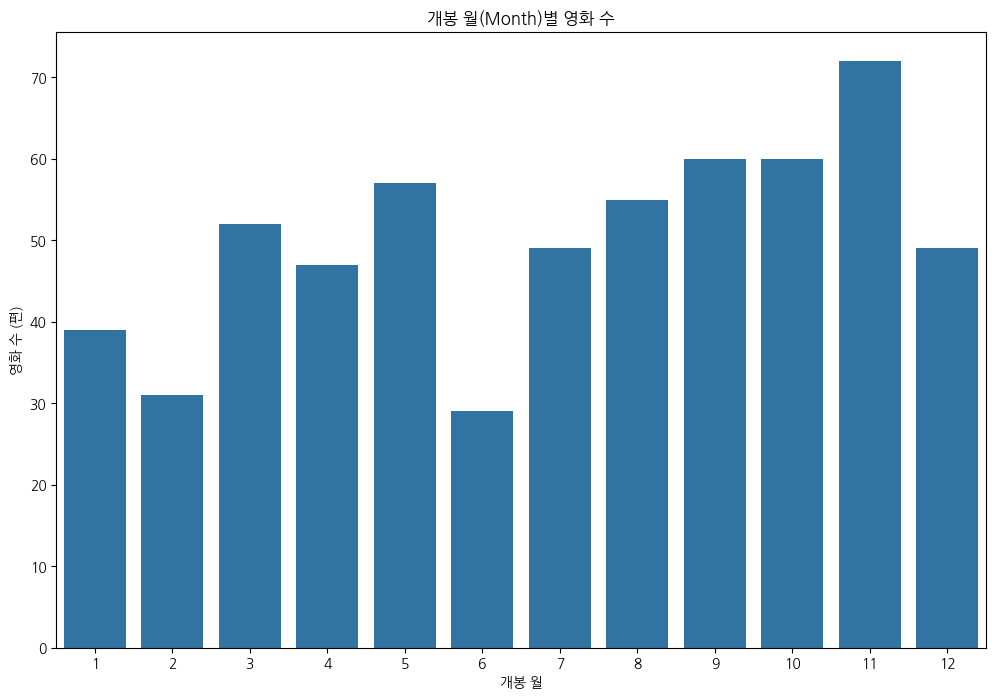

In [ ]:
month_count = train['release_month'].value_counts().sort_index()

plt.figure(figsize=(12, 8))
sns.barplot(x=month_count.index, y=month_count.values)
plt.title('개봉 월(Month)별 영화 수')
plt.xlabel('개봉 월')
plt.ylabel('영화 수 (편)')
plt.show()

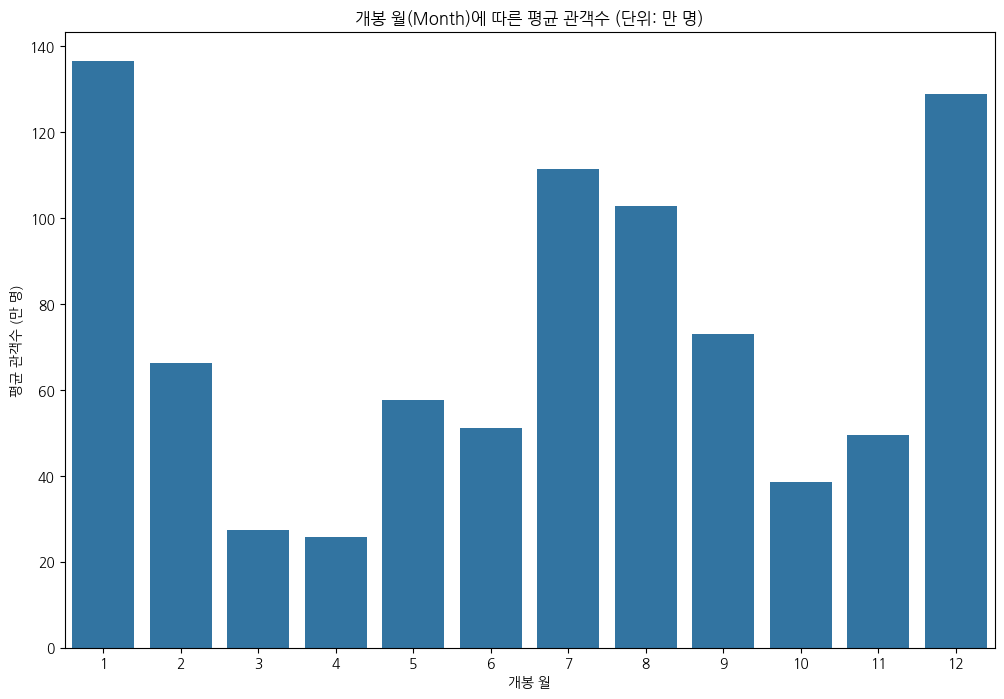

In [ ]:
month_num = train.groupby('release_month')['box_off_num'].mean() / 10000

plt.figure(figsize=(12,8))
sns.barplot(x=month_num.index, y=month_num.values)
plt.title('개봉 월(Month)에 따른 평균 관객수 (단위: 만 명)')
plt.xlabel('개봉 월')
plt.ylabel('평균 관객수 (만 명)')
plt.show()

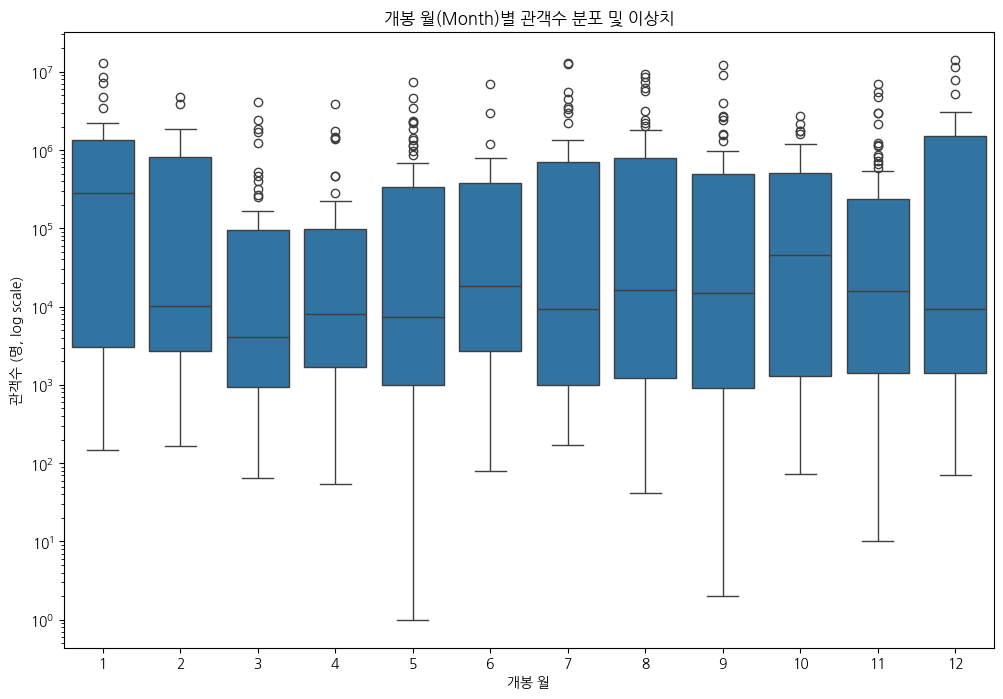

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=train, x='release_month', y='box_off_num')

plt.yscale('log')
plt.title('개봉 월(Month)별 관객수 분포 및 이상치')
plt.xlabel('개봉 월')
plt.ylabel('관객수 (명, log scale)')
plt.show()

### 개봉 분기에 따른 관객수

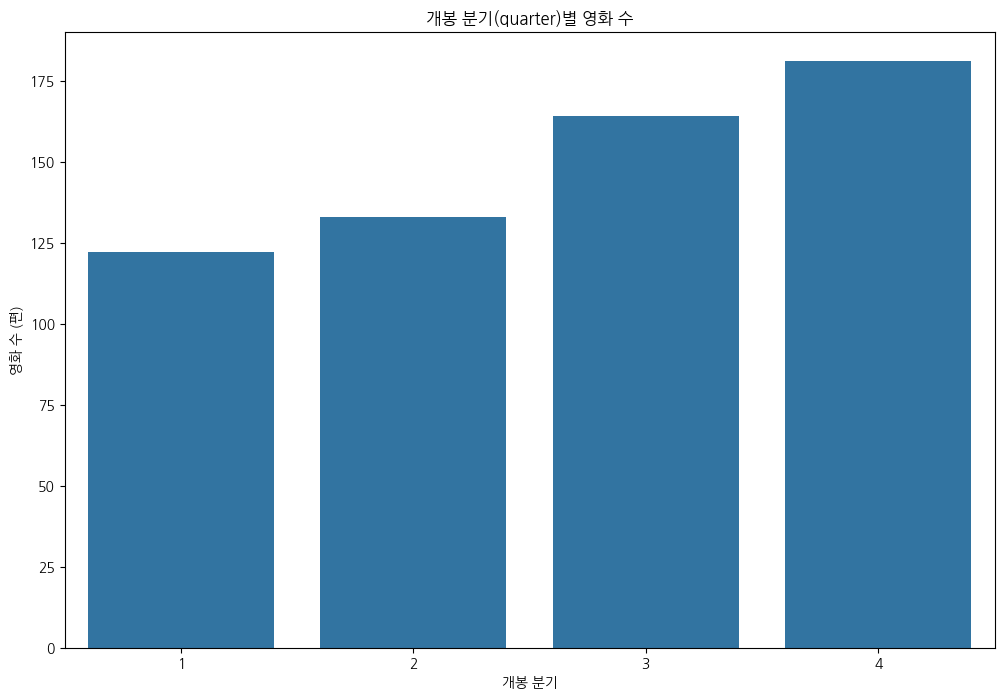

In [ ]:
quarter_count = train['release_quarter'].value_counts().sort_index()

plt.figure(figsize=(12, 8))
sns.barplot(x=quarter_count.index, y=quarter_count.values)
plt.title('개봉 분기(quarter)별 영화 수')
plt.xlabel('개봉 분기')
plt.ylabel('영화 수 (편)')
plt.show()

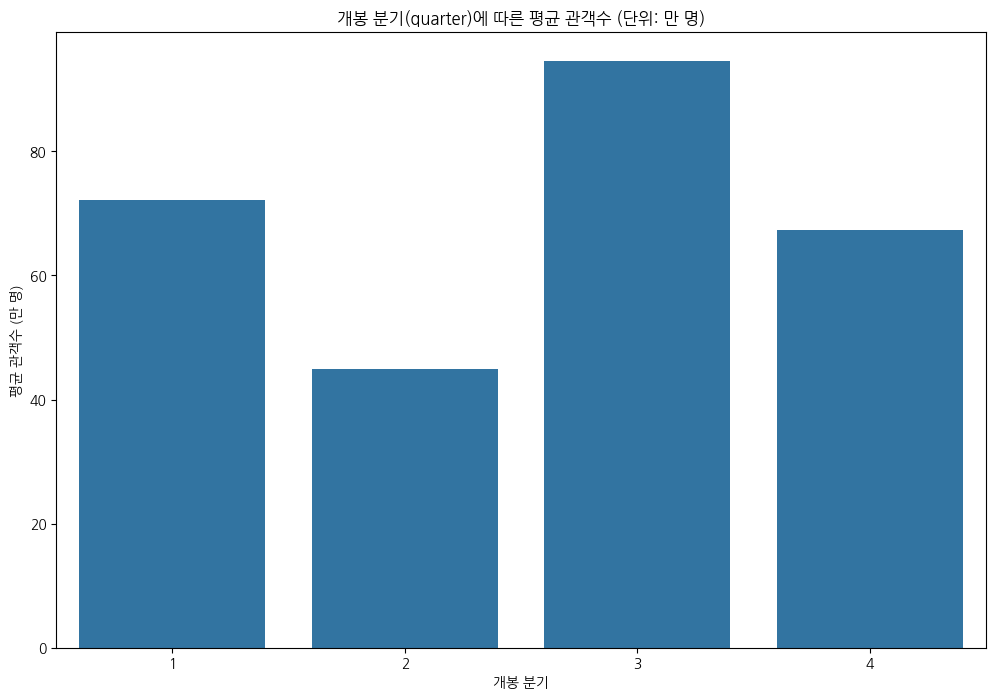

In [ ]:
quarter_num = train.groupby('release_quarter')['box_off_num'].mean() / 10000

plt.figure(figsize=(12,8))
sns.barplot(x=quarter_num.index, y=quarter_num.values)
plt.title('개봉 분기(quarter)에 따른 평균 관객수 (단위: 만 명)')
plt.xlabel('개봉 분기')
plt.ylabel('평균 관객수 (만 명)')
plt.show()

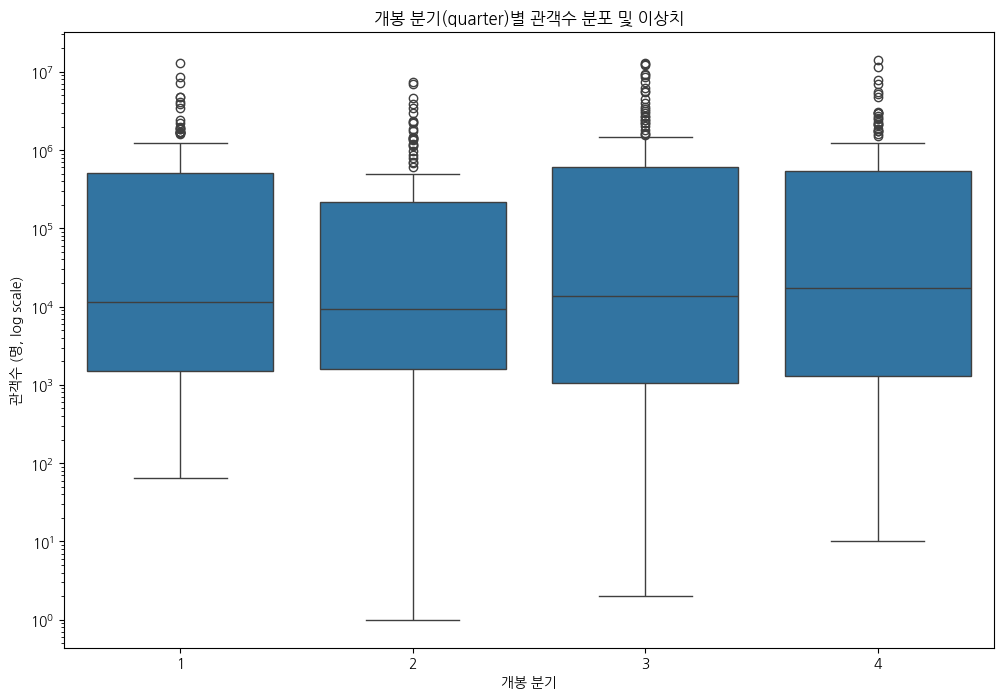

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=train, x='release_quarter', y='box_off_num')

plt.yscale('log')
plt.title('개봉 분기(quarter)별 관객수 분포 및 이상치')
plt.xlabel('개봉 분기')
plt.ylabel('관객수 (명, log scale)')
plt.show()

### 개봉 요일에 따른 관객수

In [ ]:
print('전체 영화 수:', train['release_dayofweek'].value_counts().sum(), '\n')
print('개봉 요일별 영화 수:\n', train['release_dayofweek'].value_counts())

전체 영화 수: 600 

개봉 요일별 영화 수:
 release_dayofweek
Thursday     484
Wednesday    107
Monday         4
Friday         2
Tuesday        2
Saturday       1
Name: count, dtype: int64


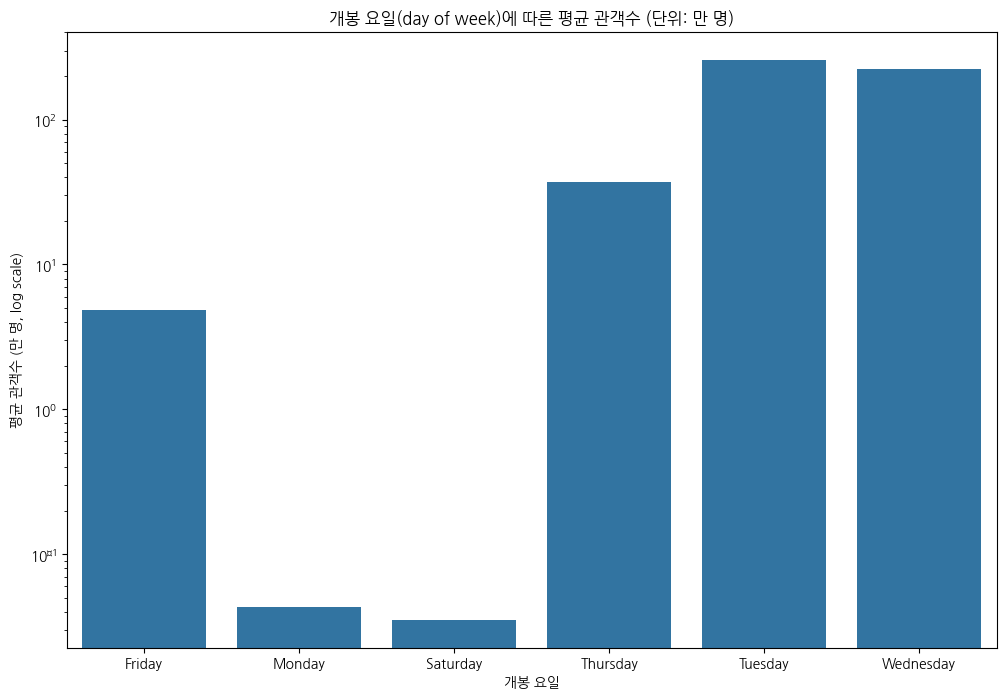

In [ ]:
dayofweek_num = train.groupby('release_dayofweek')['box_off_num'].mean() / 10000

plt.figure(figsize=(12,8))
sns.barplot(x=dayofweek_num.index, y=dayofweek_num.values)

plt.yscale('log')
plt.title('개봉 요일(day of week)에 따른 평균 관객수 (단위: 만 명)')
plt.xlabel('개봉 요일')
plt.ylabel('평균 관객수 (만 명, log scale)')
plt.show()

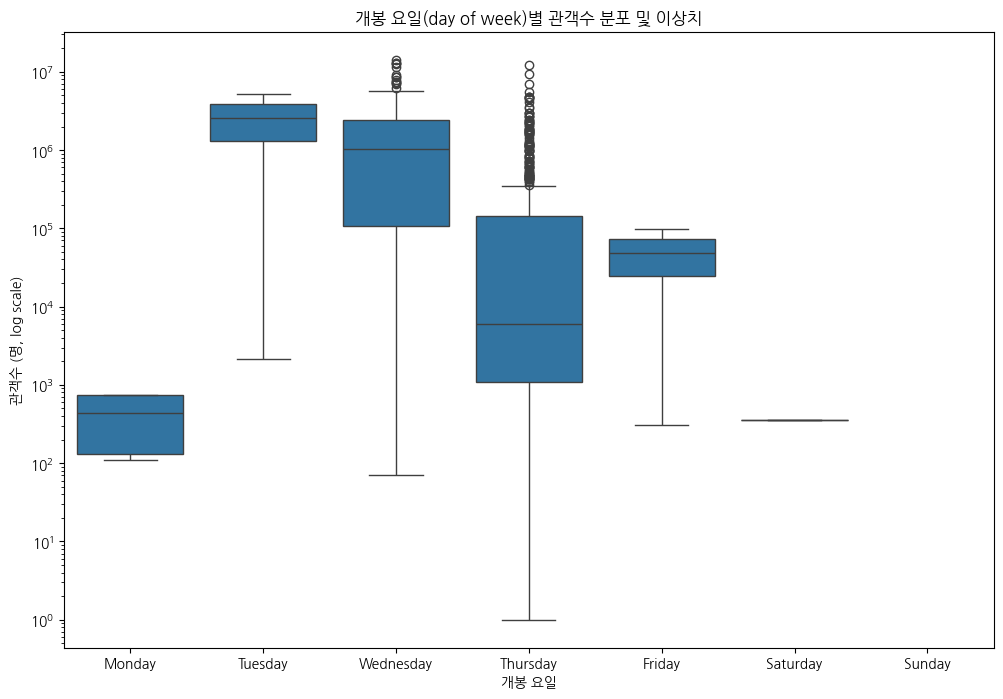

In [ ]:
plt.figure(figsize=(12, 8))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=train, x='release_dayofweek', y='box_off_num', order=day_order)

plt.yscale('log')
plt.title('개봉 요일(day of week)별 관객수 분포 및 이상치')
plt.xlabel('개봉 요일')
plt.ylabel('관객수 (명, log scale)')
plt.show()

### 그래프

시즌별 개봉 영화 편수:
is_peak
비성수기               408
성수기 (7,8,12,1월)    192
Name: count, dtype: int64

성수기 vs 비성수기 관객 수 통계량 비교


,편수,평균관객수,중위관객수,최대관객수
is_peak,,,,
비성수기,408,483659,11101,12323595
"성수기 (7,8,12,1월)",192,1185291,15967,14262766



[Mann-Whitney U 검정 결과]
 - Statistic: 43001.5, p-value: 5.2974e-02
 -> [유의하지 않음] 성수기와 비성수기 간 관객 수 차이가 통계적으로 유의하지 않습니다.


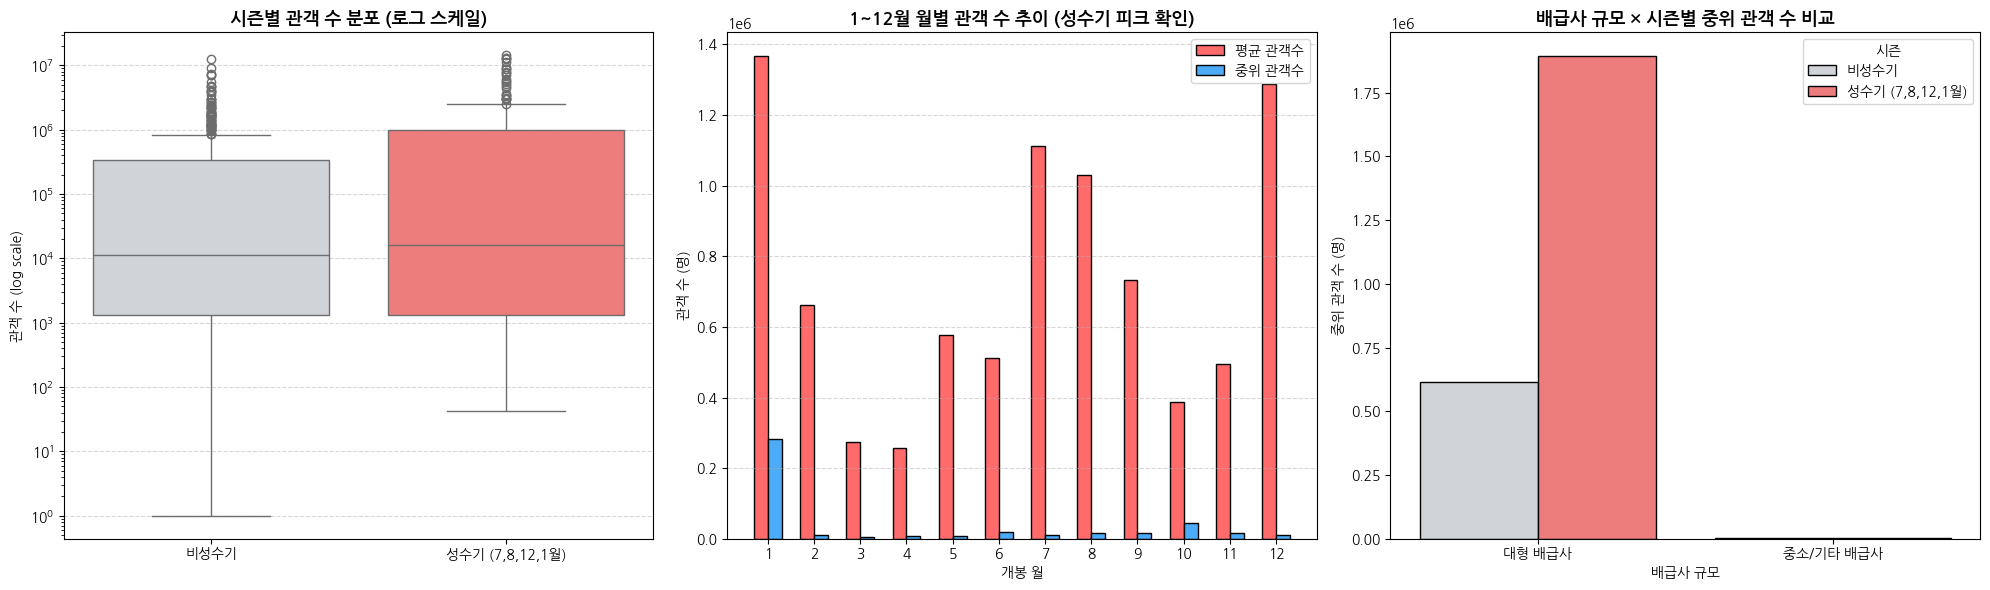

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# -------------------------------------------------------------------------
# 1. 개봉월 추출 및 성수기/비성수기 라벨링
# -------------------------------------------------------------------------
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_month'] = train['release_time'].dt.month

# 한국 영화 시장 기준 성수기: 7, 8, 12, 1월
peak_months = [7, 8, 12, 1]
train['is_peak'] = train['release_month'].apply(
    lambda x: '성수기 (7,8,12,1월)' if x in peak_months else '비성수기'
)

# 배급사 규모 라벨링 (상위 4대 메이저 vs 기타)
major_distributors = ['CJ', '롯데', 'NEW', '쇼박스']
train['dist_type'] = train['distributor'].apply(
    lambda x: '대형 배급사' if any(m in str(x) for m in major_distributors) else '중소/기타 배급사'
)

print("시즌별 개봉 영화 편수:")
print(train['is_peak'].value_counts())


# -------------------------------------------------------------------------
# 2. 기초 통계량 및 비모수 통계 검정 (Mann-Whitney U Test)
# -------------------------------------------------------------------------
peak_group = train[train['is_peak'] == '성수기 (7,8,12,1월)']['box_off_num']
off_group = train[train['is_peak'] == '비성수기']['box_off_num']

stat, p = mannwhitneyu(peak_group, off_group, alternative='two-sided')

print("\n" + "=" * 65)
print("성수기 vs 비성수기 관객 수 통계량 비교")
print("=" * 65)
summary = train.groupby('is_peak')['box_off_num'].agg(
    편수='count',
    평균관객수=lambda x: int(x.mean()),
    중위관객수=lambda x: int(x.median()),
    최대관객수='max'
)
display(summary)

print("\n[Mann-Whitney U 검정 결과]")
print(f" - Statistic: {stat:.1f}, p-value: {p:.4e}")
if p < 0.05:
    print(" -> [유의미함] 성수기와 비성수기 간 관객 수 분포에 통계적으로 유의한 차이가 있습니다. (p < 0.05)")
else:
    print(" -> [유의하지 않음] 성수기와 비성수기 간 관객 수 차이가 통계적으로 유의하지 않습니다.")


# -------------------------------------------------------------------------
# 3. 시각화 (3개 플롯 구성)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3-1. 성수기 vs 비성수기 관객수 분포 (로그 스케일 박스플롯)
sns.boxplot(
    data=train,
    x='is_peak',
    y='box_off_num',
    palette=['#ced4da', '#ff6b6b'],
    ax=axes[0],
    order=['비성수기', '성수기 (7,8,12,1월)']
)
axes[0].set_yscale('log')
axes[0].set_title('시즌별 관객 수 분포 (로그 스케일)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('관객 수 (log scale)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 3-2. 월별(1~12월) 평균 및 중위 관객 수 추이
month_stats = train.groupby('release_month')['box_off_num'].agg(['mean', 'median'])
x_months = np.arange(1, 13)

axes[1].bar(month_stats.index - 0.15, month_stats['mean'], width=0.3, label='평균 관객수', color='#ff6b6b', edgecolor='black')
axes[1].bar(month_stats.index + 0.15, month_stats['median'], width=0.3, label='중위 관객수', color='#4dabf7', edgecolor='black')
axes[1].set_title('1~12월 월별 관객 수 추이 (성수기 피크 확인)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('개봉 월')
axes[1].set_ylabel('관객 수 (명)')
axes[1].set_xticks(x_months)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 3-3. 배급사 규모와 성수기의 상호작용 (대형 배급사 vs 중소 배급사)
dist_peak_summary = train.groupby(['dist_type', 'is_peak'])['box_off_num'].median().reset_index()
sns.barplot(
    data=dist_peak_summary,
    x='dist_type',
    y='box_off_num',
    hue='is_peak',
    palette=['#ced4da', '#ff6b6b'],
    ax=axes[2],
    edgecolor='black'
)
axes[2].set_title('배급사 규모 × 시즌별 중위 관객 수 비교', fontsize=13, fontweight='bold')
axes[2].set_xlabel('배급사 규모')
axes[2].set_ylabel('중위 관객 수 (명)')
axes[2].legend(title='시즌')

plt.tight_layout()
plt.show()

## 9. 스태프 수 대비 관객수

### EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# -------------------------------------------------------------------------
# 1. 파생변수 생성 (스태프 수 구간, 1인당 관객수)
# -------------------------------------------------------------------------
# 0으로 나누는 것을 방지하기 위해 num_staff + 1
train['box_per_staff'] = train['box_off_num'] / (train['num_staff'] + 1)

# 스태프 수 구간 분할 (독립/소규모 ~ 대형 블록버스터)
bins = [-1, 50, 150, 300, train['num_staff'].max()]
labels = ['소규모 (0~50명)', '중소규모 (51~150명)', '중대규모 (151~300명)', '대규모 (301명 이상)']
train['staff_group'] = pd.cut(train['num_staff'], bins=bins, labels=labels)

### 그래프

스태프 수 vs 관객 수 상관분석 결과
1. Pearson 상관계수  : 0.5443 (p-value: 1.4414e-47)
2. Spearman 순위상관 : 0.6948 (p-value: 1.1332e-87)
 -> [유의미함] 스태프 수가 많을수록 관객 수가 증가하는 유의한 순위 상관관계가 존재합니다. (p < 0.05)

스태프 수 구간별 관객 수 및 효율 요약


,편수,평균관객수,중위관객수,스태프1인당중위관객수
staff_group,,,,
소규모 (0~50명),242,63607,1816,195
중소규모 (51~150명),136,259177,3780,37
중대규모 (151~300명),98,829479,242381,1186
대규모 (301명 이상),124,2362732,1365310,3297


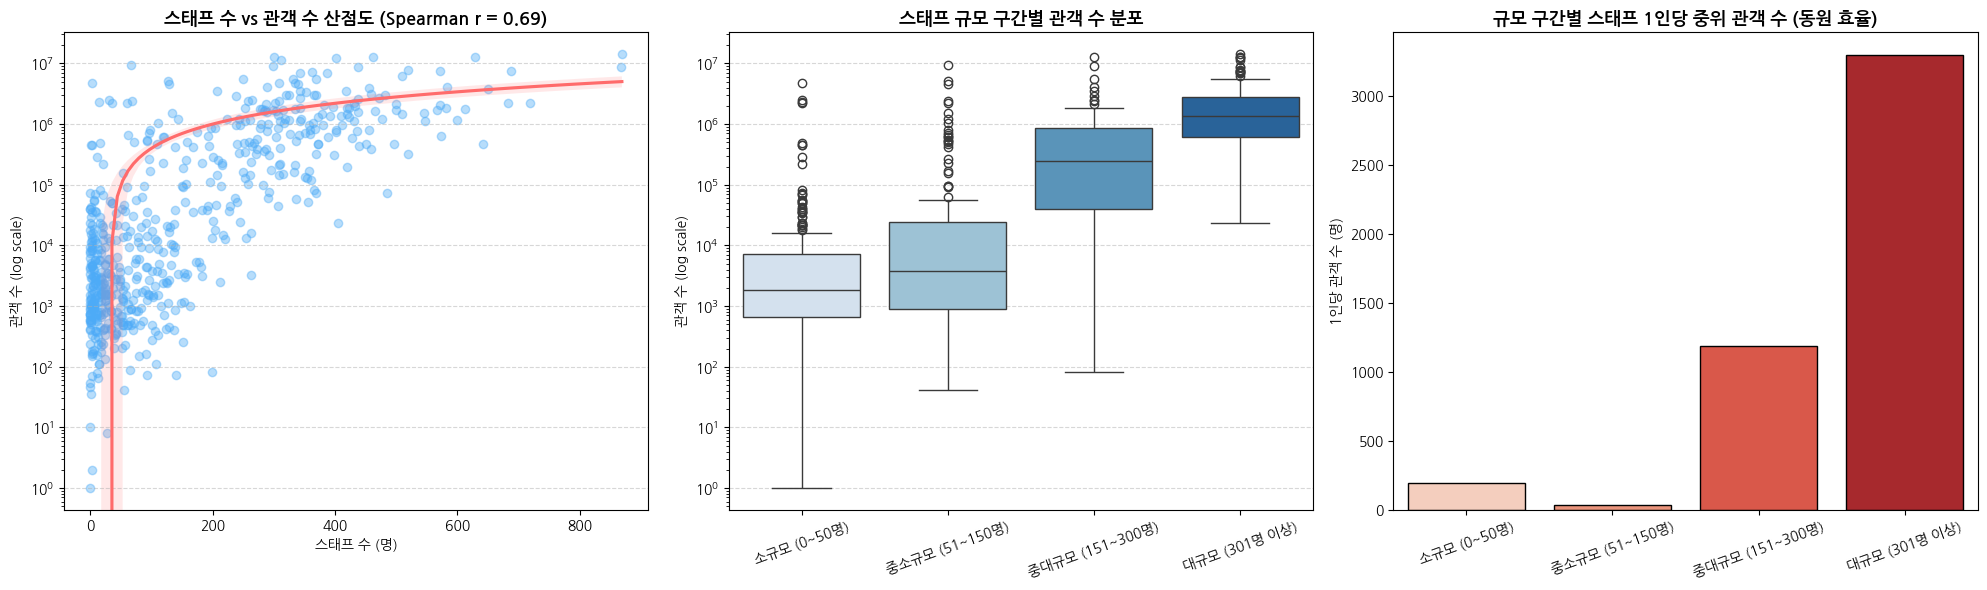

In [ ]:
# -------------------------------------------------------------------------
# 2. 상관분석 및 통계 검정
# -------------------------------------------------------------------------
# 피어슨 상관계수 (선형 관계)
p_corr, p_pval = pearsonr(train['num_staff'], train['box_off_num'])
# 스피어만 순위 상관계수 (비선형 단조 관계)
s_corr, s_pval = spearmanr(train['num_staff'], train['box_off_num'])

print("=" * 65)
print("스태프 수 vs 관객 수 상관분석 결과")
print("=" * 65)
print(f"1. Pearson 상관계수  : {p_corr:.4f} (p-value: {p_pval:.4e})")
print(f"2. Spearman 순위상관 : {s_corr:.4f} (p-value: {s_pval:.4e})")

if s_pval < 0.05:
    print(" -> [유의미함] 스태프 수가 많을수록 관객 수가 증가하는 유의한 순위 상관관계가 존재합니다. (p < 0.05)")
else:
    print(" -> [유의하지 않음] 유의미한 상관관계가 없습니다.")

print("\n" + "=" * 65)
print("스태프 수 구간별 관객 수 및 효율 요약")
print("=" * 65)
summary_staff = train.groupby('staff_group', observed=False).agg(
    편수=('box_off_num', 'count'),
    평균관객수=('box_off_num', lambda x: int(x.mean())),
    중위관객수=('box_off_num', lambda x: int(x.median())),
    스태프1인당중위관객수=('box_per_staff', lambda x: int(x.median()))
)
display(summary_staff)


# -------------------------------------------------------------------------
# 3. 시각화 (3개 플롯)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 3-1. 산점도 및 회귀 추세선 (로그 스케일)
# 0값 방지를 위해 +1 로그 변환 시각화
sns.regplot(
    data=train,
    x='num_staff',
    y='box_off_num',
    scatter_kws={'alpha': 0.4, 'color': '#4dabf7'},
    line_kws={'color': '#ff6b6b'},
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title(f'스태프 수 vs 관객 수 산점도 (Spearman r = {s_corr:.2f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('스태프 수 (명)')
axes[0].set_ylabel('관객 수 (log scale)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 3-2. 스태프 수 구간별 관객 수 분포 (박스플롯)
sns.boxplot(
    data=train,
    x='staff_group',
    y='box_off_num',
    palette='Blues',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('스태프 규모 구간별 관객 수 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('관객 수 (log scale)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 3-3. 스태프 규모 구간별 '스태프 1인당 중위 관객 수' (효율성)
sns.barplot(
    data=train,
    x='staff_group',
    y='box_per_staff',
    estimator=np.median,
    errorbar=None,
    palette='Reds',
    edgecolor='black',
    ax=axes[2]
)
axes[2].set_title('규모 구간별 스태프 1인당 중위 관객 수 (동원 효율)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('1인당 관객 수 (명)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(관객수 알려지지 않은 영화 제외) x 관객수

### EDA & 데이터 전처리

In [ ]:
# (주어진 데이터에서) 영화가 2개 이상인 감독 이름
director_names = train['director'].value_counts()[train['director'].value_counts() >= 2].index
director_list = director_names.tolist()
print(director_list)

['홍상수', '우민호', '전규환', '신재호', '장률', '노진수', '장진', '김기덕', '오멸', '전수일', '신연식', '박철수', '윤여창', '김현석', '김봉은', '조성규', '조조 히데오', '권칠인', '김조광수', '정성복', '강우석', '이준익', '안재훈', '이상호', '유하', '장건재', '박훈정', '전화성', '임성구', '문승욱', '김지훈', '이전', '이환경', '김영탁', '이수성', '노덕', '김석윤', '허은희', '김성훈', '김동원', '김성수', '전재홍', '김휘', '조근현', '연상호', '최시형', '김대우', '임상수', '박정범', '김건', '이석훈', '신현원', '육상효', '김정훈', '김태식', '임우성', '이철하', '최위안', '이송희일', '임순례', '송일곤', '송해성', '이해영', '허종호', '추창민', '최동훈', '이상우', '오영두', '김태경', '임권택', '김곡', '구혜선', '권형진', '박배일', '이광국', '김상진', '이숭환', '진승현', '손석', '류승완', '이종필', '한상희', '이원석', '민규동', '강형철', '류훈', '정기훈', '이재용', '이창재', '박용집', '황인호', '곽경택', '김상철', '부지영', '전계수', '허철', '김태용', '신수원', '남기웅']


In [ ]:
# 해당 감독들의 데이터만 필터링한 데이터프레임 생성
director_names_df = train[train['director'].isin(director_names)]

# 그룹 객체 생성
grouped = director_names_df.groupby('director')

# 특정 감독 데이터 가져오기
grouped.get_group('홍상수')

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,...,is_major_dist,release_month,is_major,release_day,release_dayofweek,release_quarter,is_peak,dist_type,box_per_staff,staff_group
15,자유의 언덕,(주) 영화제작전원사,드라마,2014-09-04,67,청소년 관람불가,홍상수,NaN,0,52,...,False,9,중소/기타 배급사,4,Thursday,3,비성수기,중소/기타 배급사,741.830189,중소규모 (51~150명)
19,하하하,스폰지,드라마,2010-05-05,115,청소년 관람불가,홍상수,NaN,0,74,...,False,5,중소/기타 배급사,5,Wednesday,2,비성수기,중소/기타 배급사,760.386667,중소규모 (51~150명)
115,북촌방향,(주) 영화사조제,드라마,2011-09-08,79,청소년 관람불가,홍상수,NaN,0,55,...,False,9,중소/기타 배급사,8,Thursday,3,비성수기,중소/기타 배급사,825.214286,중소규모 (51~150명)
164,지금은맞고그때는틀리다,(주)NEW,드라마,2015-09-24,121,청소년 관람불가,홍상수,39317.0,1,16,...,True,9,대형 배급사,24,Thursday,3,비성수기,대형 배급사,4749.058824,소규모 (0~50명)
331,다른나라에서,(주) 영화제작전원사,드라마,2012-05-31,89,청소년 관람불가,홍상수,NaN,0,70,...,False,5,중소/기타 배급사,31,Thursday,2,비성수기,중소/기타 배급사,438.042254,중소규모 (51~150명)
506,우리 선희,(주) 영화제작전원사,드라마,2013-09-12,89,청소년 관람불가,홍상수,NaN,0,8,...,False,9,중소/기타 배급사,12,Thursday,3,비성수기,중소/기타 배급사,7680.222222,소규모 (0~50명)
523,옥희의 영화,스폰지,드라마,2010-09-16,80,청소년 관람불가,홍상수,NaN,0,57,...,False,9,중소/기타 배급사,16,Thursday,3,비성수기,중소/기타 배급사,640.034483,중소규모 (51~150명)


In [ ]:
# release_time을 datetime으로 변환 후 감독 및 개봉일 기준 오름차순 정렬
train['release_time'] = pd.to_datetime(train['release_time'])
train = train.sort_values(by=['director', 'release_time']).reset_index(drop=True)

# 감독별 이전 영화 수 재계산
train['new_dir_prev_num'] = train.groupby('director').cumcount()

# 현재 영화 이전(shift(1)) 영화들의 관객수 누적 평균(expanding().mean()) 계산
train['new_dir_prev_bfnum'] = train.groupby('director')['box_off_num'].shift(1).groupby(train['director']).expanding().mean().reset_index(drop=True)

In [ ]:
check_cols = ['title', 'release_time', 'box_off_num', 'new_dir_prev_num', 'new_dir_prev_bfnum']
train[train['director'] == '홍상수'][check_cols]

,title,release_time,box_off_num,new_dir_prev_num,new_dir_prev_bfnum
581,하하하,2010-05-05,57029,0,NaN
582,옥희의 영화,2010-09-16,37122,1,57029.000000
583,북촌방향,2011-09-08,46212,2,47075.500000
584,다른나라에서,2012-05-31,31101,3,46787.666667
585,우리 선희,2013-09-12,69122,4,42866.000000
586,자유의 언덕,2014-09-04,39317,5,48117.200000
587,지금은맞고그때는틀리다,2015-09-24,80734,6,46650.500000


In [ ]:
train['new_dir_prev_bfnum'] = train['new_dir_prev_bfnum'].fillna(0)

In [ ]:
# 로그 변환
train['log_dir_prev_bfnum'] = np.log1p(train['new_dir_prev_bfnum'])
train['log_box_off_num'] = np.log1p(train['box_off_num'])

### 그래프 그리기

이전 영화 평균 관객수와 현재 관객수의 상관계수: 0.1637


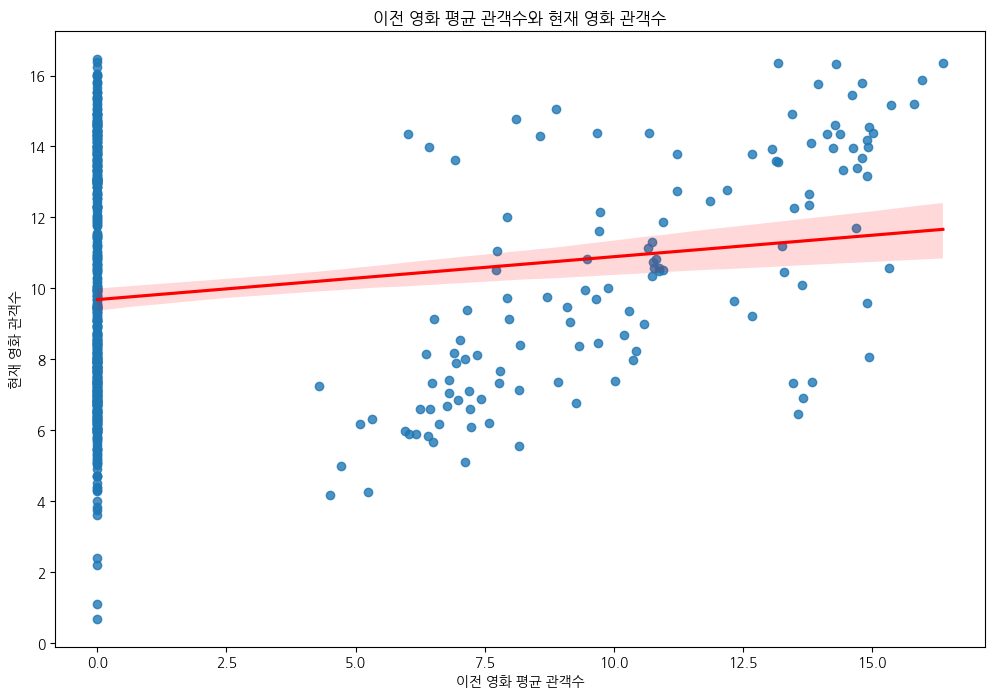

In [ ]:
corr_all = train['log_dir_prev_bfnum'].corr(train['log_box_off_num'])
print(f"이전 영화 평균 관객수와 현재 관객수의 상관계수: {corr_all:.4f}")

plt.figure(figsize=(12, 8))
sns.regplot(data=train, x='log_dir_prev_bfnum', y='log_box_off_num', line_kws={'color': 'red'})

plt.title('이전 영화 평균 관객수와 현재 영화 관객수')
plt.xlabel('이전 영화 평균 관객수')
plt.ylabel('현재 영화 관객수')
plt.show()

이전 영화가 있는 감독의 상관계수: 0.6903


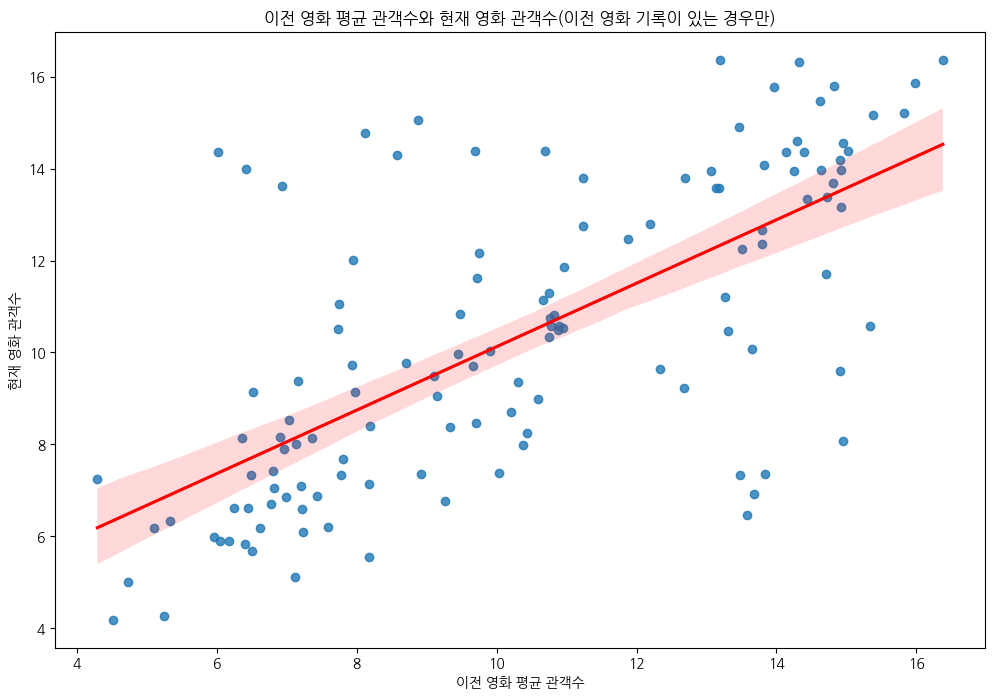

In [ ]:
# 이전 영화가 1개 이상 있는 데이터만 필터링
prev_exist = train[train['new_dir_prev_num'] > 0].copy()

corr_exist = prev_exist['log_dir_prev_bfnum'].corr(prev_exist['log_box_off_num'])
print(f"이전 영화가 있는 감독의 상관계수: {corr_exist:.4f}")

plt.figure(figsize=(12,8))
sns.regplot(
    data=prev_exist,
    x='log_dir_prev_bfnum',
    y='log_box_off_num',
    line_kws={'color': 'red'}
)

plt.title('이전 영화 평균 관객수와 현재 영화 관객수(이전 영화 기록이 있는 경우만)')
plt.xlabel('이전 영화 평균 관객수')
plt.ylabel('현재 영화 관객수')
plt.show()